In [19]:
np.random.seed(29)

import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\eso8GKofnumUkahs")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\eso8GKofnumUkahs'

In [15]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, TunedThresholdClassifierCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, make_scorer

from src.data.prepare_data import x_y_split, tt_split

In [4]:
data = pd.read_csv('data/raw/ACME-HappinessSurvey2020.csv')

x, y = x_y_split(data)

x_train, x_test, y_train, y_test = tt_split(x, y)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


### XGB Classifier Report

Best Parameters:
{'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.001, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 1}
Best Threshold: 0.49596554
Training Data Accuracy:
0.65
Testing Data Accuracy:
0.5
              precision    recall  f1-score   support

           0       0.43      0.25      0.32        12
           1       0.53      0.71      0.61        14

    accuracy                           0.50        26
   macro avg       0.48      0.48      0.46        26
weighted avg       0.48      0.50      0.47        26



### Confusion Matrix

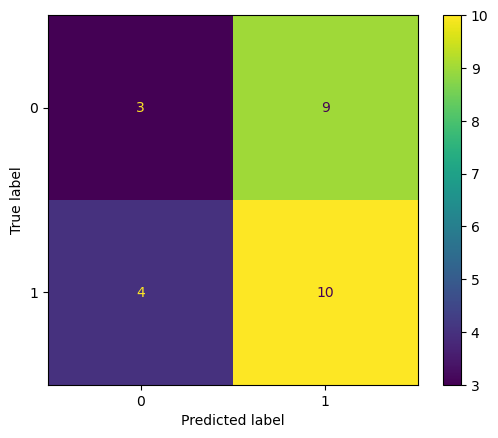

### Feature Importance

,Feature,Importance
0,X1,0.858
2,X3,0.088
4,X5,0.055
1,X2,0.000
3,X4,0.000
5,X6,0.000


In [18]:
param_grid = {
    'n_estimators': [200, 500, 1000, 2000],
    'learning_rate': [0.001, 0.005, 0.01],
    'max_depth': [2, 3, 5],
    'min_child_weight': [2, 3, 5],
    'gamma': [0],
    'reg_alpha': [0.1, 1],
    'reg_lambda': [0.1, 1],
    'colsample_bytree': [1],
    'subsample': [1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=29),
    param_grid,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(x_train, y_train)
xgb_model = xgb_grid.best_estimator_

threshold_model = TunedThresholdClassifierCV(
    xgb_model,
    scoring='accuracy',
    cv=5,
    thresholds=100,
    n_jobs=-1
)

threshold_model.fit(x_train, y_train)

best_threshold = threshold_model.best_threshold_
best_accuracy = threshold_model.best_score_

y_pred = threshold_model.predict(x_test)

display(Markdown('### XGB Classifier Report'))

if best_threshold < 0.1 or best_threshold > 0.9:
    display(Markdown('### ******BAD THRESHOLD******'))

print('Best Parameters:')
print(xgb_grid.best_params_)

print("Best Threshold:", best_threshold)

print('Training Data Accuracy:')
print(round(threshold_model.score(x_train,y_train), 2))
print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_.round(3)
})

importance = importance.sort_values('Importance', ascending=False)

display(Markdown('### Feature Importance'))
display(importance)